# Formativa 1 - Análisis exploratorio e inferencial

**Proyecto:** Rain in Australia  
**Equipo:** Grupo 6  
**Integrantes:** Gonzalo Bouldres; Eduardo Contreras; Luis Díaz Giral  
**Docente:** Dr. Jean Paul Maidana González  
**Curso:** MCDI501 - Estadística Computacional para la Toma de Decisiones

## Formulación estadística del problema

La base **Rain in Australia** contiene observaciones meteorológicas diarias registradas en múltiples estaciones climáticas de Australia. La variable objetivo es `RainTomorrow`, que indica si se registra lluvia al día siguiente.

El análisis de esta Formativa 1 se centra en aplicar estadística descriptiva, estimación puntual, intervalos de confianza y pruebas de hipótesis para caracterizar la relación entre variables meteorológicas del día actual y la ocurrencia de lluvia al día siguiente.

## Fase 1: Configuración, carga y auditoría de datos faltantes

Esta fase inicial configura el entorno de trabajo, carga el archivo `weatherAUS.csv`, verifica sus dimensiones y cuantifica los datos faltantes por variable.

In [1]:
# Librerías, configuración y rutas
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency

sns.set_theme(style="whitegrid", context="notebook")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


def resolver_raiz_local(start: Path | None = None) -> Path:
    current = Path.cwd() if start is None else Path(start)
    candidates = [
        current,
        current.parent,
        current.parent.parent,
        current / "semana1",
        current.parent / "semana1",
    ]

    for candidate in candidates:
        if (candidate / "data" / "raw" / "weatherAUS.csv").exists():
            return candidate

    matches = list(current.rglob("weatherAUS.csv"))
    if not matches and current.parent.exists():
        matches = list(current.parent.rglob("weatherAUS.csv"))

    raw_matches = [
        path
        for path in matches
        if path.parent.name == "raw" and path.parent.parent.name == "data"
    ]

    if raw_matches:
        return raw_matches[0].parent.parent.parent

    if matches:
        return matches[0].parent

    raise FileNotFoundError("No se encontró weatherAUS.csv en data/raw ni en rutas cercanas.")


project_root = resolver_raiz_local()
raw_path = project_root / "data" / "raw" / "weatherAUS.csv"
processed_dir = project_root / "data" / "processed"
docs_dir = project_root / "docs"
tables_dir = docs_dir / "tables"
figures_dir = docs_dir / "figures"
src_dir = project_root / "src"

for folder in [processed_dir, docs_dir, tables_dir, figures_dir, src_dir]:
    folder.mkdir(parents=True, exist_ok=True)

sys.path.append(str(src_dir))
from estadistica_utils import media_ic_t, proporcion_ic_wilson, cohens_d_independiente

print("Dataset:", raw_path.relative_to(project_root).as_posix())
print("Carpetas de salida configuradas correctamente.")

Dataset: data/raw/weatherAUS.csv
Carpetas de salida configuradas correctamente.


In [2]:
# Carga del dataset
df_raw = pd.read_csv(raw_path, parse_dates=["Date"])

print("Base cargada correctamente.")
print("Dimensiones originales:", df_raw.shape)
display(df_raw.head())

Base cargada correctamente.
Dimensiones originales: (145460, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4000,22.9000,0.6000,NaN,NaN,W,44.0000,W,WNW,20.0000,24.0000,71.0000,22.0000,"1,007.7000","1,007.1000",8.0000,NaN,16.9000,21.8000,No,No
1,2008-12-02,Albury,7.4000,25.1000,0.0000,NaN,NaN,WNW,44.0000,NNW,WSW,4.0000,22.0000,44.0000,25.0000,"1,010.6000","1,007.8000",NaN,NaN,17.2000,24.3000,No,No
2,2008-12-03,Albury,12.9000,25.7000,0.0000,NaN,NaN,WSW,46.0000,W,WSW,19.0000,26.0000,38.0000,30.0000,"1,007.6000","1,008.7000",NaN,2.0000,21.0000,23.2000,No,No
3,2008-12-04,Albury,9.2000,28.0000,0.0000,NaN,NaN,NE,24.0000,SE,E,11.0000,9.0000,45.0000,16.0000,"1,017.6000","1,012.8000",NaN,NaN,18.1000,26.5000,No,No
4,2008-12-05,Albury,17.5000,32.3000,1.0000,NaN,NaN,W,41.0000,ENE,NW,7.0000,20.0000,82.0000,33.0000,"1,010.8000","1,006.0000",7.0000,8.0000,17.8000,29.7000,No,No


In [3]:
# Inspección inicial
resumen_base = pd.DataFrame(
    {
        "indicador": [
            "filas",
            "columnas",
            "fecha_minima",
            "fecha_maxima",
            "localidades",
            "variables_numericas",
            "variables_categoricas",
        ],
        "valor": [
            df_raw.shape[0],
            df_raw.shape[1],
            df_raw["Date"].min(),
            df_raw["Date"].max(),
            df_raw["Location"].nunique(),
            df_raw.select_dtypes(include=[np.number]).shape[1],
            df_raw.select_dtypes(exclude=[np.number]).shape[1],
        ],
    }
)

resumen_base.to_csv(tables_dir / "01_resumen_base.csv", index=False, encoding="utf-8-sig")
display(resumen_base)

tipos_datos = df_raw.dtypes.astype(str).reset_index()
tipos_datos.columns = ["variable", "tipo_dato"]
tipos_datos.to_csv(tables_dir / "02_tipos_datos.csv", index=False, encoding="utf-8-sig")
display(tipos_datos)

,indicador,valor
0,filas,145460
1,columnas,23
2,fecha_minima,2007-11-01 00:00:00
3,fecha_maxima,2017-06-25 00:00:00
4,localidades,49
5,variables_numericas,16
6,variables_categoricas,7


,variable,tipo_dato
0,Date,datetime64[us]
1,Location,str
2,MinTemp,float64
3,MaxTemp,float64
4,Rainfall,float64
5,Evaporation,float64
6,Sunshine,float64
7,WindGustDir,str
8,WindGustSpeed,float64
9,WindDir9am,str


In [4]:
# Preparación inicial y variables derivadas
df = df_raw.copy()

for column in ["RainToday", "RainTomorrow"]:
    df[column + "_bin"] = df[column].map({"No": 0, "Yes": 1})

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month


def season_australia(month):
    if pd.isna(month):
        return np.nan
    month = int(month)
    if month in [12, 1, 2]:
        return "Summer"
    if month in [3, 4, 5]:
        return "Autumn"
    if month in [6, 7, 8]:
        return "Winter"
    if month in [9, 10, 11]:
        return "Spring"
    return np.nan


df["Season"] = df["Month"].apply(season_australia)

display(
    df[
        [
            "Date",
            "Location",
            "RainToday",
            "RainTomorrow",
            "RainToday_bin",
            "RainTomorrow_bin",
            "Year",
            "Month",
            "Season",
        ]
    ].head()
)

,Date,Location,RainToday,RainTomorrow,RainToday_bin,RainTomorrow_bin,Year,Month,Season
0,2008-12-01,Albury,No,No,0.0000,0.0000,2008,12,Summer
1,2008-12-02,Albury,No,No,0.0000,0.0000,2008,12,Summer
2,2008-12-03,Albury,No,No,0.0000,0.0000,2008,12,Summer
3,2008-12-04,Albury,No,No,0.0000,0.0000,2008,12,Summer
4,2008-12-05,Albury,No,No,0.0000,0.0000,2008,12,Summer


,variable,n_faltantes,porcentaje_faltantes
6,Sunshine,69835,48.0100
5,Evaporation,62790,43.1700
18,Cloud3pm,59358,40.8100
17,Cloud9am,55888,38.4200
15,Pressure9am,15065,10.3600
16,Pressure3pm,15028,10.3300
9,WindDir9am,10566,7.2600
7,WindGustDir,10326,7.1000
8,WindGustSpeed,10263,7.0600
14,Humidity3pm,4507,3.1000


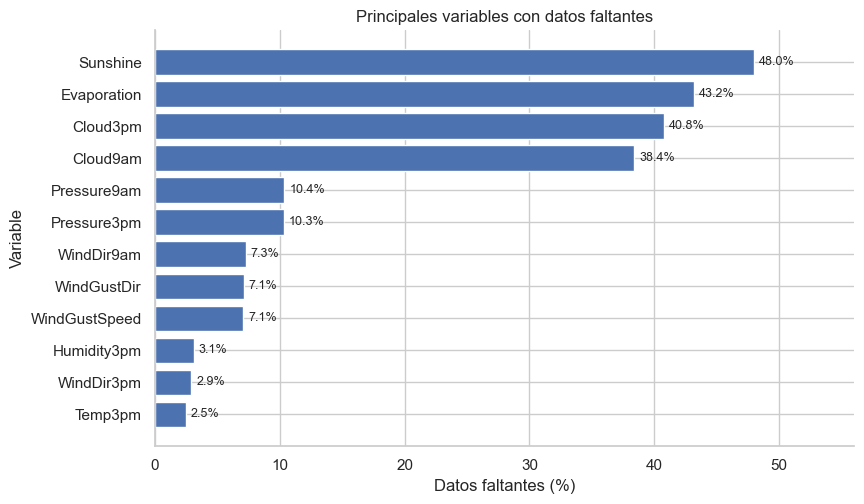

In [5]:
# Auditoría de datos faltantes
missing_table = (
    df.isna()
    .sum()
    .rename("n_faltantes")
    .reset_index()
    .rename(columns={"index": "variable"})
)
missing_table["porcentaje_faltantes"] = (
    missing_table["n_faltantes"] / len(df) * 100
)
missing_table = missing_table.sort_values("porcentaje_faltantes", ascending=False)
missing_table.to_csv(
    tables_dir / "03_auditoria_datos_faltantes.csv",
    index=False,
    encoding="utf-8-sig",
)

display(missing_table.head(12).round(2))

fig, ax = plt.subplots(figsize=(8.8, 5.2))
plot_data = missing_table.head(12).sort_values("porcentaje_faltantes")
ax.barh(plot_data["variable"], plot_data["porcentaje_faltantes"])
ax.set_xlabel("Datos faltantes (%)")
ax.set_ylabel("Variable")
ax.set_title("Principales variables con datos faltantes")
for i, value in enumerate(plot_data["porcentaje_faltantes"]):
    ax.text(value + 0.4, i, f"{value:.1f}%", va="center", fontsize=9)
ax.set_xlim(0, max(plot_data["porcentaje_faltantes"]) + 8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(figures_dir / "fig_01_datos_faltantes.png", dpi=300, bbox_inches="tight")
plt.show()

### Justificación metodológica sobre datos faltantes

El dataset presenta omisiones naturales en variables meteorológicas como `Evaporation`, `Sunshine`, `Cloud9am` y `Cloud3pm`. Estas ausencias son coherentes con limitaciones operacionales de medición, diferencias entre estaciones meteorológicas y disponibilidad parcial de ciertos instrumentos en el estudio.

Por lo tanto, **para nuestro caso no se generarán datos faltantes artificiales bajo un mecanismo MCAR**, ya que el dataset seleccionado ya contiene datos faltantes reales en varias variables. Esta decisión evita alterar artificialmente la estructura original de la base y mantiene la trazabilidad del análisis exploratorio.

## Fase 2: Aplicación de estadística descriptiva

Esta fase separa variables continuas y categóricas, calcula métricas descriptivas para variables meteorológicas clave y complementa el análisis con una matriz de correlación de Pearson. Además, se presentan visualizaciones para evaluar distribución, dispersión y comportamiento por grupo de `RainTomorrow`.

In [6]:
# Segmentación de variables continuas y categóricas
variables_continuas = df.select_dtypes(include=[np.number]).columns.tolist()
variables_categoricas = df.select_dtypes(exclude=[np.number]).columns.tolist()

segmentacion_variables = pd.DataFrame(
    {
        "tipo_variable": ["continua/numerica", "categorica/no_numerica"],
        "cantidad": [len(variables_continuas), len(variables_categoricas)],
        "variables": [
            ", ".join(variables_continuas),
            ", ".join(variables_categoricas),
        ],
    }
)

segmentacion_variables.to_csv(
    tables_dir / "04_segmentacion_variables.csv",
    index=False,
    encoding="utf-8-sig",
)

display(segmentacion_variables)

,tipo_variable,cantidad,variables
0,continua/numerica,20,"MinTemp, MaxTemp, Rainfall, Evaporation, Sunsh..."
1,categorica/no_numerica,8,"Date, Location, WindGustDir, WindDir9am, WindD..."


In [7]:
# Métricas descriptivas de variables meteorológicas clave
variables_clave = ["MinTemp", "MaxTemp", "Humidity3pm", "Pressure3pm"]

descriptive_table = df[variables_clave].agg(
    ["count", "mean", "median", "std", "var", "min", "max"]
).T

q1 = df[variables_clave].quantile(0.25)
q3 = df[variables_clave].quantile(0.75)

descriptive_table["q1"] = q1
descriptive_table["q3"] = q3
descriptive_table["iqr"] = q3 - q1
descriptive_table["missing_pct"] = df[variables_clave].isna().mean() * 100

descriptive_table = descriptive_table[
    ["count", "missing_pct", "mean", "median", "std", "var", "q1", "q3", "iqr", "min", "max"]
]

descriptive_export = descriptive_table.round(3).reset_index().rename(columns={"index": "variable"})
descriptive_export.to_csv(
    tables_dir / "05_estadistica_descriptiva_variables_clave.csv",
    index=False,
    encoding="utf-8-sig",
)

display(descriptive_export)

,variable,count,missing_pct,mean,median,std,var,q1,q3,iqr,min,max
0,MinTemp,"143,975.0000",1.0210,12.1940,12.0000,6.3980,40.9410,7.6000,16.9000,9.3000,-8.5000,33.9000
1,MaxTemp,"144,199.0000",0.8670,23.2210,22.6000,7.1190,50.6810,17.9000,28.2000,10.3000,-4.8000,48.1000
2,Humidity3pm,"140,953.0000",3.0980,51.5390,52.0000,20.7960,432.4700,37.0000,66.0000,29.0000,0.0000,100.0000
3,Pressure3pm,"130,432.0000",10.3310,"1,015.2560","1,015.2000",7.0370,49.5250,"1,010.4000","1,020.0000",9.6000,977.1000,"1,039.6000"


### Matriz de correlación de variables meteorológicas

Para complementar la estadística descriptiva univariada, se calcula una matriz de correlación de Pearson entre variables meteorológicas seleccionadas. También se incorporan `RainToday_bin` y `RainTomorrow_bin`, codificadas como 0 = No y 1 = Yes. En estos casos, la correlación con variables continuas se interpreta como una asociación lineal exploratoria de tipo punto-biserial.

Este análisis permite identificar relaciones iniciales entre temperatura, humedad, presión, viento y ocurrencia de lluvia, sin asumir causalidad entre las variables.

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday_bin,RainTomorrow_bin
MinTemp,1.0000,0.7370,0.1040,0.1770,-0.2330,0.0060,-0.4510,-0.4610,0.9020,0.7090,0.0560,0.0840
MaxTemp,0.7370,1.0000,-0.0750,0.0680,-0.5040,-0.5090,-0.3320,-0.4270,0.8870,0.9850,-0.2290,-0.1590
Rainfall,0.1040,-0.0750,1.0000,0.1340,0.2240,0.2560,-0.1680,-0.1270,0.0110,-0.0800,0.5020,0.2390
WindGustSpeed,0.1770,0.0680,0.1340,1.0000,-0.2150,-0.0260,-0.4590,-0.4140,0.1500,0.0330,0.1560,0.2340
Humidity9am,-0.2330,-0.5040,0.2240,-0.2150,1.0000,0.6670,0.1390,0.1870,-0.4710,-0.4980,0.3540,0.2570
Humidity3pm,0.0060,-0.5090,0.2560,-0.0260,0.6670,1.0000,-0.0280,0.0520,-0.2210,-0.5580,0.3790,0.4460
Pressure9am,-0.4510,-0.3320,-0.1680,-0.4590,0.1390,-0.0280,1.0000,0.9610,-0.4230,-0.2870,-0.1900,-0.2460
Pressure3pm,-0.4610,-0.4270,-0.1270,-0.4140,0.1870,0.0520,0.9610,1.0000,-0.4700,-0.3900,-0.1060,-0.2260
Temp9am,0.9020,0.8870,0.0110,0.1500,-0.4710,-0.2210,-0.4230,-0.4700,1.0000,0.8610,-0.0970,-0.0260
Temp3pm,0.7090,0.9850,-0.0800,0.0330,-0.4980,-0.5580,-0.2870,-0.3900,0.8610,1.0000,-0.2350,-0.1920


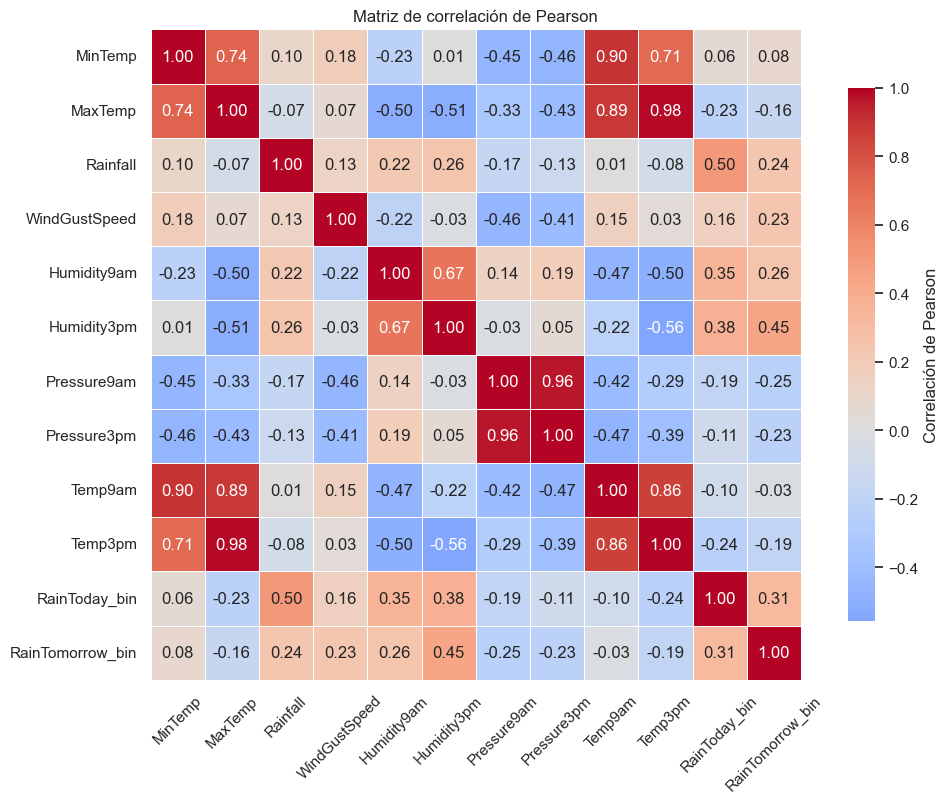

In [8]:
# Matriz de correlación de Pearson
correlation_vars = [
    "MinTemp",
    "MaxTemp",
    "Rainfall",
    "WindGustSpeed",
    "Humidity9am",
    "Humidity3pm",
    "Pressure9am",
    "Pressure3pm",
    "Temp9am",
    "Temp3pm",
    "RainToday_bin",
    "RainTomorrow_bin",
]

correlation_vars = [variable for variable in correlation_vars if variable in df.columns]
correlation_matrix = df[correlation_vars].corr(method="pearson")

correlation_export = (
    correlation_matrix
    .round(3)
    .reset_index()
    .rename(columns={"index": "variable"})
)

correlation_export.to_csv(
    tables_dir / "06_matriz_correlacion_pearson.csv",
    index=False,
    encoding="utf-8-sig",
)

display(correlation_matrix.round(3))

fig, ax = plt.subplots(figsize=(10.8, 8.2))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.4,
    square=True,
    cbar_kws={"shrink": 0.82, "label": "Correlación de Pearson"},
    ax=ax,
)
ax.set_title("Matriz de correlación de Pearson")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig(
    figures_dir / "fig_03_matriz_correlacion_pearson.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

La matriz de correlación evidencia relaciones esperadas entre variables meteorológicas. Destaca la alta asociación positiva entre temperaturas medidas en distintos horarios, como `MaxTemp` y `Temp3pm`, además de la relación directa entre `Humidity9am` y `Humidity3pm`. Respecto de `RainTomorrow_bin`, la asociación lineal más relevante dentro de las variables seleccionadas se observa con `Humidity3pm`, lo que respalda su uso posterior en la estimación de intervalos de confianza y en la prueba de hipótesis principal.

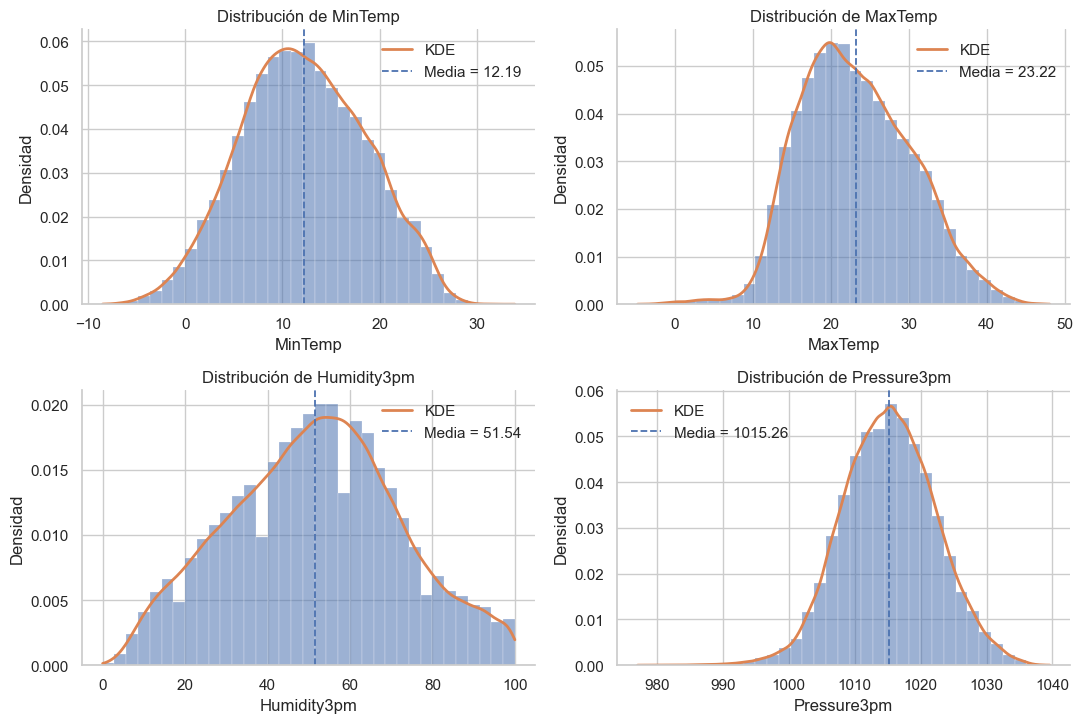

In [9]:
# Histogramas con KDE para variables clave
fig, axes = plt.subplots(2, 2, figsize=(11, 7.4))
axes = axes.ravel()

for ax, variable in zip(axes, variables_clave):
    serie = df[variable].dropna().astype(float)
    ax.hist(
        serie,
        bins=35,
        density=True,
        alpha=0.55,
        edgecolor="white",
        linewidth=0.3,
    )

    x_grid = np.linspace(serie.min(), serie.max(), 400)
    kde = stats.gaussian_kde(serie)
    ax.plot(x_grid, kde(x_grid), linewidth=2.0, label="KDE")
    ax.axvline(
        serie.mean(),
        linestyle="--",
        linewidth=1.3,
        label=f"Media = {serie.mean():.2f}",
    )
    ax.set_title(f"Distribución de {variable}")
    ax.set_xlabel(variable)
    ax.set_ylabel("Densidad")
    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(
    figures_dir / "fig_02_histogramas_kde_variables_clave.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

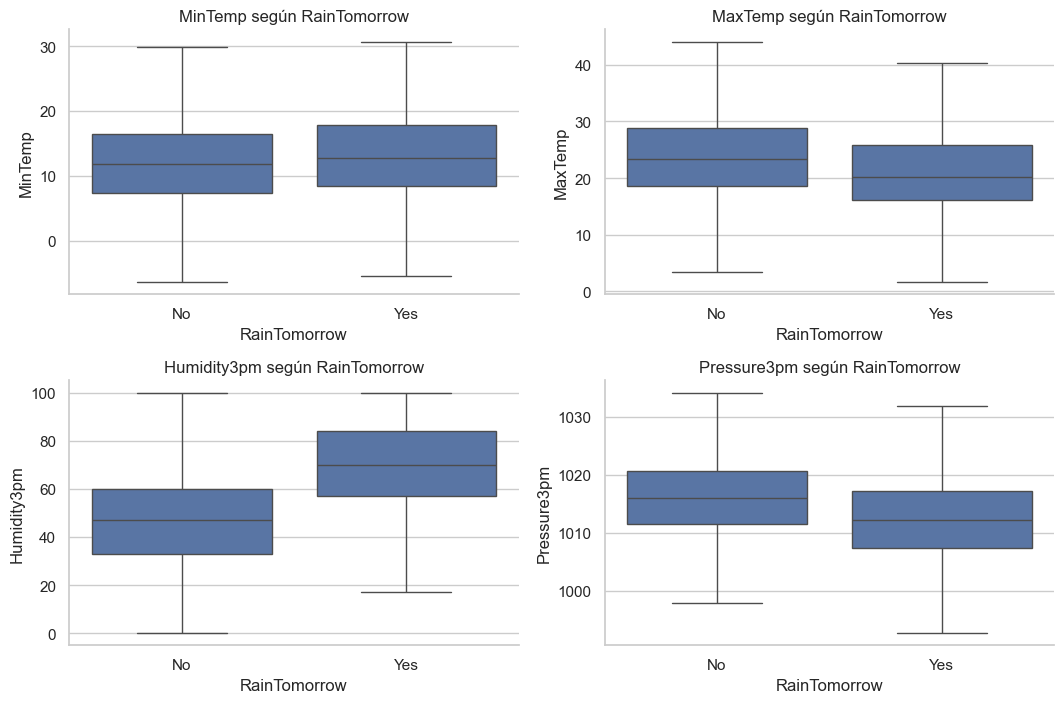

In [10]:
# Boxplots por RainTomorrow
boxplot_data = df.dropna(subset=["RainTomorrow"]).copy()

fig, axes = plt.subplots(2, 2, figsize=(10.8, 7.2))
axes = axes.ravel()

for ax, variable in zip(axes, variables_clave):
    sns.boxplot(
        data=boxplot_data,
        x="RainTomorrow",
        y=variable,
        order=["No", "Yes"],
        showfliers=False,
        ax=ax,
    )
    ax.set_title(f"{variable} según RainTomorrow")
    ax.set_xlabel("RainTomorrow")
    ax.set_ylabel(variable)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(figures_dir / "fig_04_boxplots_por_rain_tomorrow.png", dpi=300, bbox_inches="tight")
plt.show()

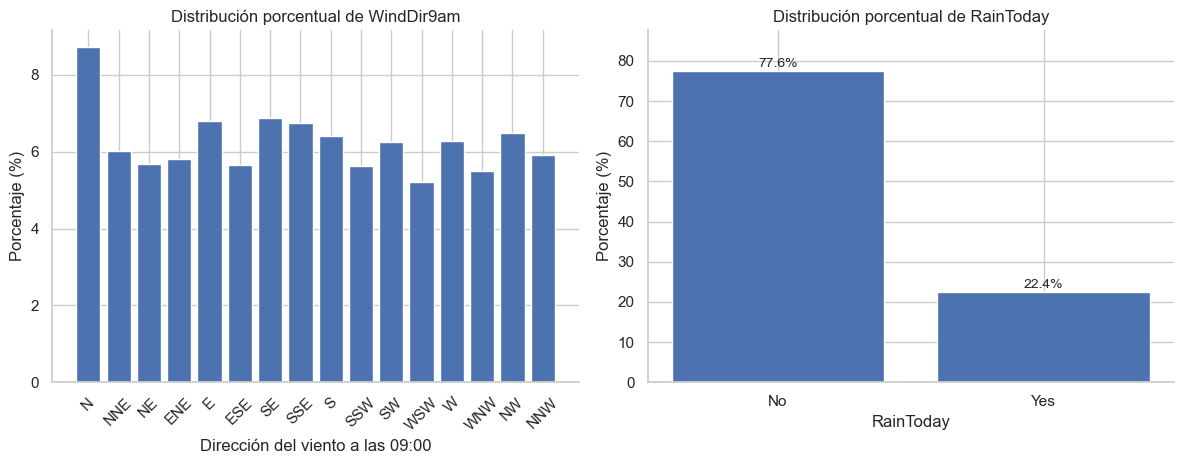

In [11]:
# Distribución de WindDir9am y RainToday
wind_order = [
    "N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE",
    "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW",
]

wind_counts = (
    df["WindDir9am"]
    .dropna()
    .value_counts()
    .reindex(wind_order)
    .dropna()
)

rain_today_counts = df["RainToday"].dropna().value_counts().reindex(["No", "Yes"])

wind_export = wind_counts.rename_axis("WindDir9am").reset_index(name="frecuencia")
wind_export["porcentaje"] = wind_export["frecuencia"] / wind_export["frecuencia"].sum() * 100
wind_export.to_csv(tables_dir / "07_frecuencia_winddir9am.csv", index=False, encoding="utf-8-sig")

rain_today_export = rain_today_counts.rename_axis("RainToday").reset_index(name="frecuencia")
rain_today_export["porcentaje"] = rain_today_export["frecuencia"] / rain_today_export["frecuencia"].sum() * 100
rain_today_export.to_csv(tables_dir / "08_frecuencia_rain_today.csv", index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].bar(wind_export["WindDir9am"], wind_export["porcentaje"])
axes[0].set_title("Distribución porcentual de WindDir9am")
axes[0].set_xlabel("Dirección del viento a las 09:00")
axes[0].set_ylabel("Porcentaje (%)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].bar(rain_today_export["RainToday"], rain_today_export["porcentaje"])
axes[1].set_title("Distribución porcentual de RainToday")
axes[1].set_xlabel("RainToday")
axes[1].set_ylabel("Porcentaje (%)")
for i, value in enumerate(rain_today_export["porcentaje"]):
    axes[1].text(i, value + 1, f"{value:.1f}%", ha="center", fontsize=10)
axes[1].set_ylim(0, max(rain_today_export["porcentaje"]) + 10)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(figures_dir / "fig_05_barras_winddir9am_raintoday.png", dpi=300, bbox_inches="tight")
plt.show()

,RainTomorrow,frecuencia,porcentaje
0,No,110316,77.5800
1,Yes,31877,22.4200


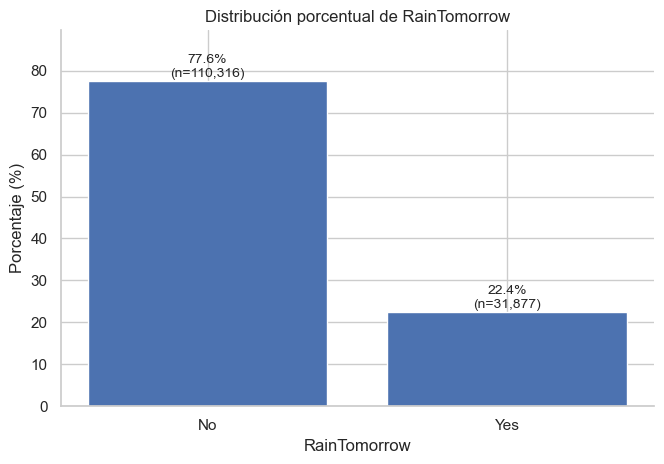

In [12]:
# Frecuencia de la variable objetivo
rain_counts = df["RainTomorrow"].dropna().value_counts().reindex(["No", "Yes"])
rain_freq = rain_counts.rename_axis("RainTomorrow").reset_index(name="frecuencia")
rain_freq["porcentaje"] = rain_freq["frecuencia"] / rain_freq["frecuencia"].sum() * 100
rain_freq.to_csv(tables_dir / "09_frecuencia_rain_tomorrow.csv", index=False, encoding="utf-8-sig")

display(rain_freq.round(2))

fig, ax = plt.subplots(figsize=(6.8, 4.8))
ax.bar(rain_freq["RainTomorrow"], rain_freq["porcentaje"])
ax.set_xlabel("RainTomorrow")
ax.set_ylabel("Porcentaje (%)")
ax.set_title("Distribución porcentual de RainTomorrow")
for i, row in rain_freq.iterrows():
    ax.text(
        i,
        row["porcentaje"] + 1,
        f'{row["porcentaje"]:.1f}%\n(n={int(row["frecuencia"]):,})',
        ha="center",
        fontsize=10,
    )
ax.set_ylim(0, max(rain_freq["porcentaje"]) + 12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(figures_dir / "fig_06_distribucion_rain_tomorrow.png", dpi=300, bbox_inches="tight")
plt.show()

## Fase 3: Estimación puntual e intervalos de confianza

Se selecciona `Humidity3pm` por su relación física directa con la formación de precipitación: mayor humedad relativa durante la tarde indica una atmósfera con mayor contenido de vapor de agua disponible. Se estima la media muestral y se construyen intervalos de confianza al 95% y 99% de acuerdo a lo solicitado en esta fase.

In [13]:
# Estimación puntual e intervalos de confianza para Humidity3pm
humidity3pm = df["Humidity3pm"].dropna()

ic_humidity_global = pd.DataFrame(
    [
        {"variable": "Humidity3pm", "confianza": "95%", **media_ic_t(humidity3pm, confianza=0.95)},
        {"variable": "Humidity3pm", "confianza": "99%", **media_ic_t(humidity3pm, confianza=0.99)},
    ]
)

ic_humidity_global.to_csv(
    tables_dir / "10_ic_humidity3pm_95_99.csv",
    index=False,
    encoding="utf-8-sig",
)

display(ic_humidity_global.round(4))

,variable,confianza,n,media,sd,se,ic_inf,ic_sup
0,Humidity3pm,95%,140953,51.5391,20.7959,0.0554,51.4306,51.6477
1,Humidity3pm,99%,140953,51.5391,20.7959,0.0554,51.3964,51.6818


,RainTomorrow,confianza,n,media,sd,se,ic_inf,ic_sup
0,No,95%,107670,46.5110,18.4890,0.0560,46.4000,46.6210
1,No,99%,107670,46.5110,18.4890,0.0560,46.3650,46.6560
2,Yes,95%,30913,68.8000,19.0370,0.1080,68.5880,69.0120
3,Yes,99%,30913,68.8000,19.0370,0.1080,68.5210,69.0790


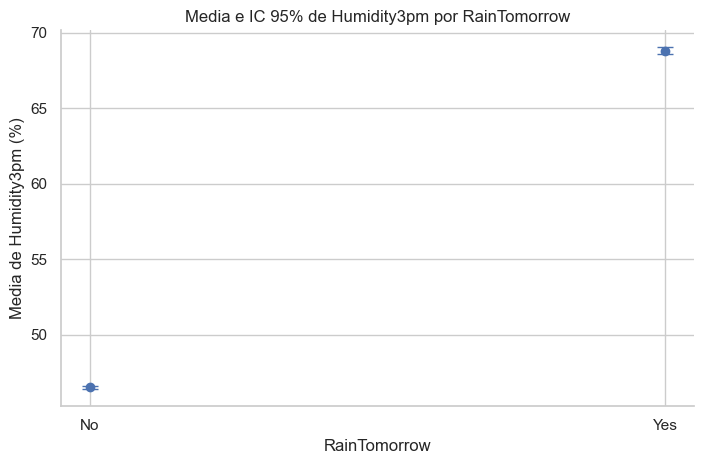

In [14]:
# Intervalos de confianza de Humidity3pm por grupo
ic_humidity_group = []

for label, val in [("No", 0), ("Yes", 1)]:
    for confidence in [0.95, 0.99]:
        result = media_ic_t(
            df.loc[df["RainTomorrow_bin"].eq(val), "Humidity3pm"],
            confianza=confidence,
        )
        result["RainTomorrow"] = label
        result["confianza"] = f"{int(confidence * 100)}%"
        ic_humidity_group.append(result)

ic_humidity_group = pd.DataFrame(ic_humidity_group)[
    ["RainTomorrow", "confianza", "n", "media", "sd", "se", "ic_inf", "ic_sup"]
]

ic_humidity_group.to_csv(
    tables_dir / "11_ic_humidity3pm_por_grupo_95_99.csv",
    index=False,
    encoding="utf-8-sig",
)

display(ic_humidity_group.round(3))

ic95_group = ic_humidity_group.query("confianza == '95%'").copy()

fig, ax = plt.subplots(figsize=(7.2, 4.8))
x_pos = np.arange(len(ic95_group))
yerr = [
    ic95_group["media"] - ic95_group["ic_inf"],
    ic95_group["ic_sup"] - ic95_group["media"],
]
ax.errorbar(
    x_pos,
    ic95_group["media"],
    yerr=yerr,
    fmt="o",
    capsize=6,
    linewidth=1.8,
    markersize=6,
)
ax.set_xticks(x_pos)
ax.set_xticklabels(ic95_group["RainTomorrow"])
ax.set_xlabel("RainTomorrow")
ax.set_ylabel("Media de Humidity3pm (%)")
ax.set_title("Media e IC 95% de Humidity3pm por RainTomorrow")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(figures_dir / "fig_07_ic95_humidity3pm_por_grupo.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretación de los intervalos de confianza

La media muestral de `Humidity3pm` representa una estimación del nivel promedio de humedad relativa registrado a las 15:00 horas en el conjunto de observaciones analizadas. El intervalo de confianza al 95% permite establecer un rango plausible para la media poblacional bajo el supuesto de repetición del muestreo, mientras que el intervalo al 99% presenta una amplitud mayor debido a que incorpora un nivel de confianza más exigente. Desde una perspectiva meteorológica, este parámetro es relevante porque permite caracterizar la disponibilidad promedio de humedad atmosférica durante la tarde, condición que puede asociarse con escenarios favorables para la ocurrencia de precipitación al día siguiente.


## Fase 4: Aplicación de pruebas de hipótesis

Se evalúa si la humedad promedio a las 15:00 es mayor en los días asociados a lluvia al día siguiente. La comparación se formula como una prueba t para dos muestras independientes. Dado que los tamaños muestrales y varianzas pueden diferir entre grupos, se utiliza la variante de Welch mediante `scipy.stats.ttest_ind` con `equal_var=False`.

- **H0:** μ(Humidity3pm | RainTomorrow = Yes) = μ(Humidity3pm | RainTomorrow = No).
- **H1:** μ(Humidity3pm | RainTomorrow = Yes) > μ(Humidity3pm | RainTomorrow = No).
- **Nivel de significancia:** α = 0,05.

In [15]:
# Prueba t de Welch unilateral para Humidity3pm
hum_no = df.loc[df["RainTomorrow_bin"].eq(0), "Humidity3pm"].dropna()
hum_yes = df.loc[df["RainTomorrow_bin"].eq(1), "Humidity3pm"].dropna()

welch_res = stats.ttest_ind(
    hum_yes,
    hum_no,
    equal_var=False,
    alternative="greater",
)

s_yes = hum_yes.var(ddof=1)
s_no = hum_no.var(ddof=1)
n_yes = len(hum_yes)
n_no = len(hum_no)

se_diff = np.sqrt(s_yes / n_yes + s_no / n_no)
df_welch = (s_yes / n_yes + s_no / n_no) ** 2 / (
    (s_yes / n_yes) ** 2 / (n_yes - 1) + (s_no / n_no) ** 2 / (n_no - 1)
)

mean_diff = hum_yes.mean() - hum_no.mean()
tcrit = stats.t.ppf(0.975, df_welch)
cohen_d = cohens_d_independiente(hum_yes, hum_no)

welch_table = pd.DataFrame(
    [
        {
            "n_lluvia": n_yes,
            "n_sin_lluvia": n_no,
            "media_lluvia": hum_yes.mean(),
            "media_sin_lluvia": hum_no.mean(),
            "diferencia_medias": mean_diff,
            "ic95_inf_diferencia": mean_diff - tcrit * se_diff,
            "ic95_sup_diferencia": mean_diff + tcrit * se_diff,
            "t": welch_res.statistic,
            "gl_welch": df_welch,
            "p_valor_unilateral": welch_res.pvalue,
            "cohen_d": cohen_d,
            "decision_alpha_0_05": "Rechazar H0"
            if welch_res.pvalue < 0.05
            else "No rechazar H0",
        }
    ]
)

welch_table.to_csv(
    tables_dir / "12_prueba_t_welch_humidity3pm_unilateral.csv",
    index=False,
    encoding="utf-8-sig",
)

display(welch_table.round(4))

,n_lluvia,n_sin_lluvia,media_lluvia,media_sin_lluvia,diferencia_medias,ic95_inf_diferencia,ic95_sup_diferencia,t,gl_welch,p_valor_unilateral,cohen_d,decision_alpha_0_05
0,30913,107670,68.8000,46.5106,22.2894,22.0502,22.5286,182.6077,"48,892.7962",0.0000,1.1975,Rechazar H0


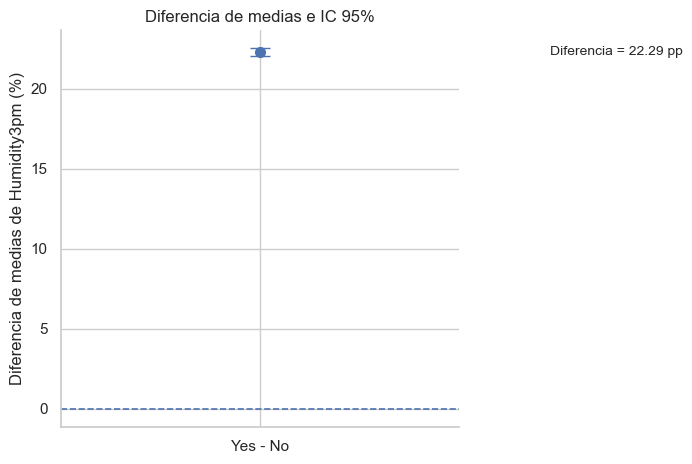

In [16]:
# Diferencia de medias e intervalo de confianza
diff_info = welch_table.iloc[0]

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.errorbar(
    x=[0],
    y=[diff_info["diferencia_medias"]],
    yerr=[
        [
            diff_info["diferencia_medias"] - diff_info["ic95_inf_diferencia"],
        ],
        [
            diff_info["ic95_sup_diferencia"] - diff_info["diferencia_medias"],
        ],
    ],
    fmt="o",
    capsize=7,
    linewidth=2,
    markersize=7,
)
ax.axhline(0, linestyle="--", linewidth=1.2)
ax.set_xticks([0])
ax.set_xticklabels(["Yes - No"])
ax.set_ylabel("Diferencia de medias de Humidity3pm (%)")
ax.set_title("Diferencia de medias e IC 95%")
ax.text(
    0.08,
    diff_info["diferencia_medias"],
    f'Diferencia = {diff_info["diferencia_medias"]:.2f} pp',
    va="center",
    fontsize=10,
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(figures_dir / "fig_08_diferencia_medias_humidity3pm.png", dpi=300, bbox_inches="tight")
plt.show()

### Poder muestral y sensibilidad del p-value

El dataset dispone de un volumen elevado de observaciones válidas para la variable objetivo, lo que incrementa la potencia estadística de la prueba t. En este contexto, incluso diferencias moderadas o pequeñas entre grupos pueden producir valores p muy bajos. Por ello, la decisión inferencial no debe sustentarse exclusivamente en la significancia estadística, sino también en la magnitud observada de la diferencia de medias y en el tamaño de efecto estimado mediante `Cohen d`, ya que estos indicadores permiten evaluar la relevancia práctica de la diferencia detectada.


### Prueba complementaria: asociación entre RainToday y RainTomorrow

Como análisis categórico complementario, se aplica una prueba chi-cuadrado de independencia con el propósito de evaluar si existe asociación estadísticamente significativa entre la ocurrencia de lluvia en el día actual (`RainToday`) y la ocurrencia de lluvia al día siguiente (`RainTomorrow`). Este procedimiento nos permite examinar si ambas variables categóricas se comportan de manera independiente o si presentan una relación sistemática dentro del conjunto de observaciones analizado.


In [17]:
# Prueba chi-cuadrado de independencia
contingency = pd.crosstab(df["RainToday"], df["RainTomorrow"])
chi2, p_value_chi, dof, expected = chi2_contingency(contingency)
cramer_v = np.sqrt(
    chi2 / (contingency.to_numpy().sum() * (min(contingency.shape) - 1))
)

chi_table = pd.DataFrame(
    [
        {
            "chi2": chi2,
            "gl": dof,
            "p_valor": p_value_chi,
            "cramers_v": cramer_v,
            "n": contingency.to_numpy().sum(),
            "decision_alpha_0_05": "Rechazar H0"
            if p_value_chi < 0.05
            else "No rechazar H0",
        }
    ]
)

contingency.reset_index().to_csv(
    tables_dir / "13_tabla_contingencia_rain_today_rain_tomorrow.csv",
    index=False,
    encoding="utf-8-sig",
)
chi_table.to_csv(
    tables_dir / "14_prueba_chi2_rain_today_rain_tomorrow.csv",
    index=False,
    encoding="utf-8-sig",
)

display(contingency)
display(chi_table.round(4))

RainTomorrow,No,Yes
RainToday,,
No,92728,16604
Yes,16858,14597


,chi2,gl,p_valor,cramers_v,n,decision_alpha_0_05
0,"13,799.4796",1,0.0000,0.3131,140787,Rechazar H0


RainTomorrow,No,Yes
RainToday,,
No,84.8100,15.1900
Yes,53.5900,46.4100


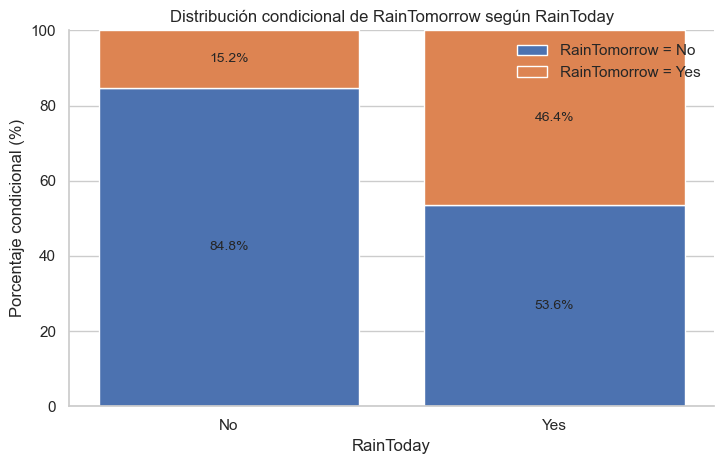

In [18]:
# Probabilidades condicionales RainToday vs RainTomorrow
conditional_prob = pd.crosstab(
    df["RainToday"],
    df["RainTomorrow"],
    normalize="index",
) * 100

conditional_prob.reset_index().to_csv(
    tables_dir / "15_probabilidades_condicionales_rain_today.csv",
    index=False,
    encoding="utf-8-sig",
)

display(conditional_prob.round(2))

fig, ax = plt.subplots(figsize=(7.4, 4.8))
bottom = np.zeros(len(conditional_prob))

for column in ["No", "Yes"]:
    values = conditional_prob[column].values
    ax.bar(conditional_prob.index, values, bottom=bottom, label=f"RainTomorrow = {column}")
    for idx, value in enumerate(values):
        ax.text(
            idx,
            bottom[idx] + value / 2,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontsize=10,
        )
    bottom += values

ax.set_ylabel("Porcentaje condicional (%)")
ax.set_xlabel("RainToday")
ax.set_title("Distribución condicional de RainTomorrow según RainToday")
ax.legend(frameon=False, loc="upper right")
ax.set_ylim(0, 100)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(figures_dir / "fig_09_condicional_rain_today_rain_tomorrow.png", dpi=300, bbox_inches="tight")
plt.show()

## Fase 5: Documentación e informe técnico

Se exportan tablas, figuras y una base procesada con variables clave para asegurar trazabilidad entre notebook, informe técnico y repositorio del proyecto.

In [19]:
# Exportación de dataset procesado e inventario de resultados
analysis_cols = (
    ["Date", "Location", "Year", "Month", "Season"]
    + variables_clave
    + ["Rainfall", "WindDir9am", "RainToday", "RainTomorrow", "RainToday_bin", "RainTomorrow_bin"]
)

df[analysis_cols].to_csv(
    processed_dir / "weatherAUS_formativa1_variables_clave.csv",
    index=False,
    encoding="utf-8-sig",
)

table_files = sorted(tables_dir.glob("*.csv"))
figure_files = sorted(figures_dir.glob("*.png"))

inventory = pd.DataFrame(
    {
        "tipo": ["tabla"] * len(table_files) + ["figura"] * len(figure_files),
        "archivo": [p.name for p in table_files] + [p.name for p in figure_files],
        "ruta": [p.relative_to(project_root).as_posix() for p in table_files]
        + [p.relative_to(project_root).as_posix() for p in figure_files],
    }
)

inventory.to_csv(
    docs_dir / "inventario_outputs_formativa1.csv",
    index=False,
    encoding="utf-8-sig",
)

display(inventory)

,tipo,archivo,ruta
0,tabla,01_resumen_base.csv,docs/tables/01_resumen_base.csv
1,tabla,02_tipos_datos.csv,docs/tables/02_tipos_datos.csv
2,tabla,03_auditoria_datos_faltantes.csv,docs/tables/03_auditoria_datos_faltantes.csv
3,tabla,04_segmentacion_variables.csv,docs/tables/04_segmentacion_variables.csv
4,tabla,05_estadistica_descriptiva_variables_clave.csv,docs/tables/05_estadistica_descriptiva_variabl...
5,tabla,06_matriz_correlacion_pearson.csv,docs/tables/06_matriz_correlacion_pearson.csv
6,tabla,07_frecuencia_winddir9am.csv,docs/tables/07_frecuencia_winddir9am.csv
7,tabla,08_frecuencia_rain_today.csv,docs/tables/08_frecuencia_rain_today.csv
8,tabla,09_frecuencia_rain_tomorrow.csv,docs/tables/09_frecuencia_rain_tomorrow.csv
9,tabla,10_ic_humidity3pm_95_99.csv,docs/tables/10_ic_humidity3pm_95_99.csv


## Interpretación preliminar y aplicaciones

Los resultados indican que `Humidity3pm` difiere de manera clara entre los días en que se registra lluvia al día siguiente y aquellos en que no ocurre. Esta diferencia es consistente con el comportamiento meteorológico esperado, ya que una mayor humedad relativa durante la tarde refleja una mayor presencia de vapor de agua en la atmósfera, condición que puede favorecer procesos asociados a precipitación posterior.

La matriz de correlación complementa esta evidencia al mostrar que `Humidity3pm` presenta una asociación lineal positiva con `RainTomorrow_bin` dentro del conjunto de variables seleccionadas. Además, se observan relaciones coherentes entre variables de temperatura, humedad y presión, lo que permite reconocer estructuras internas del dataset antes de avanzar hacia modelos predictivos más complejos.

Desde una perspectiva aplicada, este tipo de análisis puede aportar antecedentes iniciales para la toma de decisiones en distintos ámbitos. En agricultura, puede apoyar la planificación de riego, cosecha y manejo preventivo frente a posibles eventos de lluvia. En recursos hídricos, puede contribuir como insumo preliminar para anticipar condiciones favorables a aportes por precipitación. En prevención de incendios forestales, permite reconocer escenarios atmosféricos menos secos, los cuales son relevantes para una primera evaluación del riesgo meteorológico.

No obstante, estos resultados deben interpretarse como evidencia preliminar. La presente Formativa 1 se centra en un análisis descriptivo e inferencial inicial, por lo que no constituye todavía un modelo predictivo final ni incorpora de manera simultánea todas las variables meteorológicas, geográficas y estacionales que podrían influir en la ocurrencia de lluvia.